<a href="https://colab.research.google.com/github/Cxris2145/MineriaDatos2026/blob/main/ExportacionesChile2026_v2_KMeans_Metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

---

| | |
|---|---|
| **Grupo** | Grupo 1 |
| **Sección** | 002D |
| **Integrantes** | Christopher Guerrero · Luis Faundes |
| **Correos** | lu.faundes@duocuc.cl · ch.guerrerod@duocuc.cl |
| **Fecha** | Mayo 2026 |
| **Dataset** | Chile Export Products 2017–2021 |
| **Fuente** | [Kaggle — Chile Export Products](https://www.kaggle.com/datasets/michallublin/chile-export-products-20172021) |
| **Fuente Profesor** | [Github profesor](https://github.com/UXDynamicSolution/MineriaDatosDuocPAO/tree/main) |
| **Github Grupo** | [Github Nosotros](https://github.com/Cxris2145/MineriaDatos2026) |

---

</div>

---
# Ítem 1: Importación de Bibliotecas

En esta sección se cargan todas las librerías necesarias para el análisis.  
Esto debe ejecutarse **primero** antes de cualquier otra celda del notebook.

| Librería | Uso principal |
|---|---|
| `pandas` | Manipulación y análisis de datos en tablas |
| `numpy` | Operaciones matemáticas y manejo de arrays |
| `seaborn` | Visualizaciones estadísticas de alto nivel |
| `matplotlib` | Gráficos personalizados y configuración visual |
| `sklearn` | Modelos de Machine Learning y métricas |
| `scipy` | Pruebas estadísticas como la correlación de Pearson |


In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [120]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas
pd.set_option('display.max_rows', None)


#***Análisis de Exportaciones de Chile (2017 - 2021)***



Este proyecto realiza un análisis exploratorio del dataset **"ChileExport.csv"**, el cual documenta la actividad comercial de Chile con el exterior. El conjunto de datos permite segmentar la información bajo los siguientes criterios:



* **Ejes Geográficos:** Identificación de más de 220 países de destino.

* **Clasificación Sectorial:** División entre productos Mineros y No Mineros (Agropecuarios, Forestales, Servicios, etc.).



* **Métricas de Valor:** Registro de ingresos anuales en USD para evaluar el impacto económico de cada producto.



**Objetivo:** Procesar los datos nominales y cuantitativos para identificar tendencias comerciales y la composición de la matriz exportadora nacional en los últimos 5 años

#**Mapeo de tablas**

country: Categórico | Nominal | Son nombres de paises, no tienen orden

1_category:  Categórico | Nominal | Clasficación genreal, no tiene jerarquia numérica

2_category: Categórico | Nominal | Subcategoría, sigue siendo solo etiqueta

Product: Categórico | Nominal | Nombre del producto, no se puede ordenar

year: Numérico | Intervalo | Tiene orden y diferecias iguales, pero no cero absoluto

income_in_USD: Numérico | Ratio | Tiene cero real y permite proporcones

#**Descripción de las columnas del dataset**

Country: País al que se exporta el producto

1 category: Indica si la exportación es minera o no minera

2 category: Tipo de producto o sector (frutas, minería, alimentos, etc.)

Product: Producto específico exportado

Year: Año en que se realizó la exportación

Income in USD: Monto de dinero generado por la exportación en dólares


---
# Ítem 2: Carga del Dataset

Se carga el archivo `ChileExport.csv` que contiene los registros de exportaciones de Chile entre 2017 y 2021.  
`df.head()` muestra las primeras 5 filas para verificar que los datos se cargaron correctamente.


In [121]:
df = pd.read_csv("ChileExport.csv", sep=';')
df.head()

,Country,1 category,2 category,Product,Year,Income in USD
0,China,Minero,Minería,Minerales de cobre y sus concentrados,2017,6470444174
1,China,Minero,Minería,Cobre,2017,7604230274
2,China,Minero,Minería,Minerales de hierro y sus concentrados,2017,"616711446,1"
3,China,Minero,Minería,Litio,2017,234218255
4,China,Minero,Minería,Minerales de molibdeno y sus concentrados,2017,"37490057,93"


---
# Ítem 3: Limpieza de Datos

Antes de analizar, es necesario limpiar la columna `Income in USD` ya que viene en formato europeo  
(puntos como separadores de miles y comas como decimales). Se convierte al formato numérico estándar  
y se verifican valores nulos que puedan afectar los análisis posteriores.


In [122]:
# Limpieza de datos

df['Income in USD'] = df['Income in USD'].astype(str).str.strip()

# Eliminación de los puntos que separan los miles (ej: 1.500 -> 1500)
df['Income in USD'] = df['Income in USD'].str.replace('.', '', regex=False)

# Cambiamos la coma decimal por un punto (ej: 1500,50 -> 1500.50)
df['Income in USD'] = df['Income in USD'].str.replace(',', '.', regex=False)

# Se transforma a número
df['Income in USD'] = pd.to_numeric(df['Income in USD'], errors='coerce')

# ELIMINACIÓN DE REGISTROS EN BLANCO
# Quitamos las filas que no tienen categoría definida (los 15 registros vacíos)
df = df[df['1 category'] != '(en blanco)']

# Verificamos nulos finales
print(f"Valores nulos finales: {df['Income in USD'].isnull().sum()}")
print(f"Registros restantes después de limpiar blancos: {len(df)}")

Valores nulos finales: 0
Registros restantes después de limpiar blancos: 21370


Se limpian también los nombres de columnas por si tienen espacios ocultos que puedan causar errores al referenciarlas.

In [123]:
# Limpiamos los nombres de columnas por si tienen espacios raros
df.columns = df.columns.str.strip()

Se eliminan filas duplicadas para evitar que registros repetidos distorsionen los resultados del análisis.

In [124]:
# Revisamos si hay filas duplicadas en el dataset (datos repetidos)
df.duplicated().sum()

# Eliminamos duplicados si existen
df = df.drop_duplicates()

---
# Ítem 4: Exploración Inicial del Dataset

En esta etapa realizamos una exploración inicial del dataset. Revisamos cuántas filas y columnas tiene, qué tipos de datos contiene, si existen valores nulos y si los nombres de las columnas están correctos. Esta parte es importante porque nos permite conocer la calidad de los datos antes de limpiarlos, analizarlos y aplicar el modelo de Machine Learning.


`df.shape` muestra la cantidad total de filas y columnas del dataset.

In [125]:
df.shape

(21370, 6)

`df.dtypes` indica el tipo de dato de cada columna (texto, número, etc.).

In [126]:
df.dtypes

,0
Country,object
1 category,object
2 category,object
Product,object
Year,int64
Income in USD,float64


`df.columns` lista los nombres exactos de todas las columnas disponibles.

In [127]:
df.columns

Index(['Country', '1 category', '2 category', 'Product', 'Year',
       'Income in USD'],
      dtype='object')

`df.isnull().sum()` cuenta cuántos valores vacíos hay por columna. Esto permite decidir si se deben rellenar o eliminar esos registros.

In [128]:
df.isnull().sum()

,0
Country,0
1 category,0
2 category,0
Product,0
Year,0
Income in USD,0


`df.tail()`
Muestra las últimas filas del dataset.
Sirve para revisar cómo terminan los datos dentro del archivo.
Nos ayuda a comprobar que los registros finales también estén cargados correctamente.
Es útil para detectar si al final del dataset hay filas vacías, errores o datos incompletos.

In [129]:
df.tail()

,Country,1 category,2 category,Product,Year,Income in USD
21380,Gambia,No minero,Exportación de servicios calificados por Aduanas,Exportación de servicios calificados por Aduanas,2021,0.0
21381,Gambia,No minero,Resto No minería,Resto No minería,2021,0.0
21382,Groenlandia,No minero,Resto No minería,Resto No minería,2021,0.0
21383,República de Yemen,No minero,Resto No minería,Resto No minería,2021,0.0
21384,Timor Oriental,No minero,Resto No minería,Resto No minería,2021,0.0


`describe()` sobre la columna `Year` entrega un resumen estadístico: mínimo, máximo, promedio y distribución de los años disponibles.

In [130]:
df_anio = df["Year"].describe()
print(df_anio)

count    21370.000000
mean      2019.000000
std          1.414247
min       2017.000000
25%       2018.000000
50%       2019.000000
75%       2020.000000
max       2021.000000
Name: Year, dtype: float64


Este código cuenta cuántas veces aparece cada país en la columna Country y muestra el resultado en pantalla.

In [131]:
# Estados Unidos de América tuvo más transacciones o diversidad de productos exportados entre 2017 y 2021,
# seguido muy de cerca por China.

df_country = df["Country"].value_counts()
print(df_country)

Country
China                                                  350
Estados Unidos de América                              350
Japón                                                  335
Perú                                                   335
Brasil                                                 330
Canadá                                                 330
España                                                 330
Alemania                                               315
México                                                 310
Colombia                                               310
Holanda                                                305
Corea del Sur                                          305
Italia                                                 300
Reino Unido                                            295
Argentina                                              295
Bélgica                                                280
Ecuador                                         

Se revisa cuántos registros corresponden a exportaciones **mineras vs. no mineras** (primera categoría).

In [132]:
# Revisamos cuántos registros corresponden a exportaciones mineras vs. no mineras
# Ahora que limpiamos los datos, ya no deberían aparecer registros '(en blanco)'
df_category1 = df["1 category"].value_counts()
print(df_category1)

1 category
No minero    19505
Minero        1865
Name: count, dtype: int64


Se revisa la distribución de la **segunda categoría**, que representa subsectores como frutas, minería, alimentos, etc.

In [133]:
df_country = df["2 category"].value_counts()
print(df_country)

2 category
Frutas y frutos                                     5440
Otros alimentos                                     3345
Productos del mar                                   2855
Forestales y sus derivados                          2150
Otros productos relevantes                          2040
Minería                                             1865
Vitivinícola                                        1815
Resto No minería                                    1060
Exportación de servicios calificados por Aduanas     800
Name: count, dtype: int64


Se listan todos los **productos** exportados y su frecuencia.

**Nota:** Esto mide la cantidad de registros (presencia), no el valor monetario. Ayuda a identificar qué productos tienen mayor diversidad de transacciones.

In [134]:
# Listado de productos según su frecuencia de aparición en el dataset
# Verificamos que los productos '(en blanco)' hayan desaparecido
df_products = df["Product"].value_counts()
print(df_products.head(20)) # Mostramos solo el top 20 para limpieza visual

Product
Resto No minería                                    1060
Vinos                                                840
Exportación de servicios calificados por Aduanas     800
Madera y sus manufacturas                            645
Resto Forestales y sus derivados                     620
Papel y cartón y sus manufacturas                    605
Uvas                                                 600
Conservas y preparaciones de pescados y mariscos     590
Resto Otros alimentos                                590
Vinos espumosos                                      580
Manzanas                                             500
Ciruelas                                             490
Salmones y truchas                                   470
Nueces de nogal                                      460
Medicamentos                                         445
Kiwis                                                410
Mostos de uva                                        395
Resto Frutas y frutos  

---
# Ítem 5: Análisis con Gráficos (EDA)

En esta parte usamos **gráficos** para entender la información de forma visual y sencilla.

Esto nos sirve para responder preguntas clave como:
* **¿Qué vendemos más?** (Sectores y productos).
* **¿A quién le vendemos?** (Países principales).
* **¿Estamos mejorando?** (Cómo cambian las ventas con el paso de los años).

Cada gráfico tiene una pequeña explicación para que cualquiera pueda entender los resultados sin ser experto en datos.

Se crea la función `agregar_valores()` para mostrar automáticamente el número exacto sobre cada barra de los gráficos.

In [135]:
# Esta función sirve para poner los valores encima de cada barra del gráfico
def agregar_valores(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom')

### 5.1 Distribución por Categoría Principal
**Gráfico de barras:** Compara visualmente la cantidad de registros entre exportaciones mineras y no mineras.

Este gráfico muestra cuántas exportaciones pertenecen al sector minero y cuántas al resto de sectores.
Sirve para entender qué tipo de exportación aparece más en los datos. Por ejemplo, si hay muchas más exportaciones no mineras, significa que hay más variedad de productos fuera de la minería, aunque eso no necesariamente significa que generen más dinero.

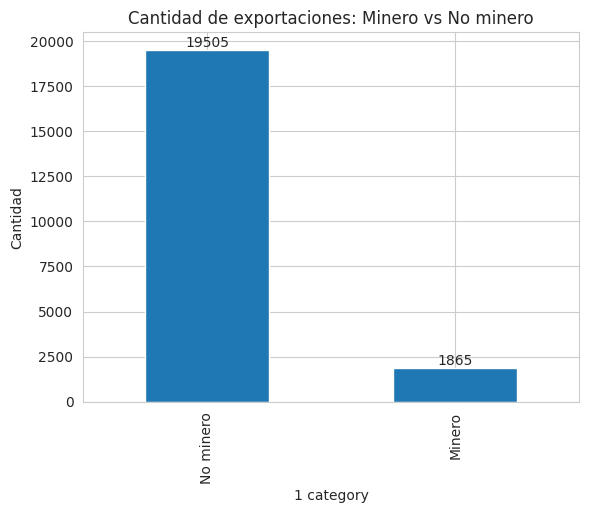

In [136]:
ax = df['1 category'].value_counts().plot(kind='bar')

plt.title("Cantidad de exportaciones: Minero vs No minero")
plt.ylabel("Cantidad")

agregar_valores(ax)

plt.show()

**Gráfico de distribución (torta):** Muestra la proporción porcentual de exportaciones mineras vs. no mineras, permitiendo entender el peso relativo de cada sector.

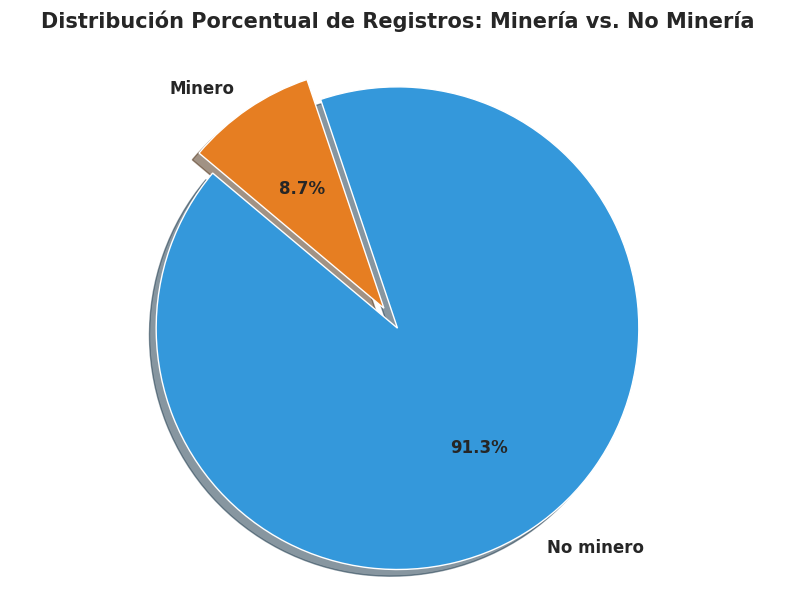

In [137]:
import matplotlib.pyplot as plt

# 1. Preparamos los datos contando las frecuencias de la categoría principal
data_torta = df['1 category'].value_counts()

# 2. Configuración estética superior
plt.figure(figsize=(10, 7))
# 'explode' separa un poco las tajadas para resaltar (0.1 para la segunda categoría)
explode = [0, 0.1] if len(data_torta) == 2 else [0] * len(data_torta)

# 3. Creamos el gráfico mejorado
plt.pie(data_torta,
        labels=data_torta.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#3498db', '#e67e22', '#95a5a6'],
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title("Distribución Porcentual de Registros: Minería vs. No Minería", fontsize=15, fontweight='bold', pad=20)
plt.axis('equal')  # Para que el gráfico sea un círculo perfecto

plt.show()

# EXPLICACIÓN MEJORADA:
# Este gráfico de torta muestra la composición de la base de datos por frecuencia de registros.
# - Notamos que el sector 'No minero' abarca la gran mayoría de las transacciones (91.3%).
# - El sector 'Minero' representa una porción menor en cantidad de envíos (8.7%), lo que resalta
#   su naturaleza de 'pocos envíos pero de altísimo valor' comparado con el resto de la economía.

### 5.2 Análisis por Subsector (Segunda Categoría)

**Gráfico de barras:** Muestra la distribución de registros entre los distintos subsectores, revelando qué tipos de productos tienen más transacciones registradas.

**Información Adicional:**
* **Diversidad Exportadora:** Sectores como *Frutas y frutos* y *Otros alimentos* lideran en cantidad de operaciones. Esto indica que Chile tiene una base exportadora muy atomizada y activa en el rubro agroindustrial.
* **Frecuencia vs. Valor:** Notarás que la *Minería* no es el primer lugar en cantidad de registros. Esto sucede porque una sola exportación minera puede valer lo mismo que cientos de envíos de frutas, por lo que la minería es de 'baja frecuencia pero alto valor'.

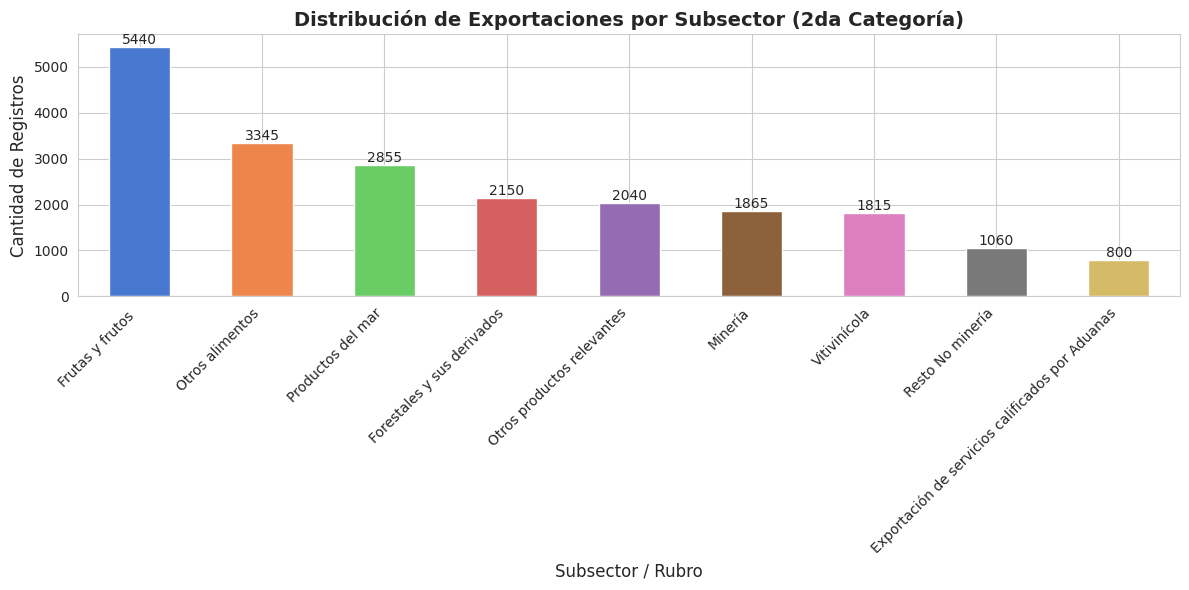

In [138]:
# 1. Obtenemos los datos de la segunda categoría
data_subsector = df['2 category'].value_counts()

# 2. Configuración del gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Usamos una paleta de colores variada
ax = data_subsector.plot(kind='bar', color=sns.color_palette('muted'))

# 3. Títulos y etiquetas
plt.title("Distribución de Exportaciones por Subsector (2da Categoría)", fontsize=14, fontweight='bold')
plt.ylabel("Cantidad de Registros", fontsize=12)
plt.xlabel("Subsector / Rubro", fontsize=12)
plt.xticks(rotation=45, ha='right')

# 4. Agregamos los valores sobre las barras
agregar_valores(ax)

plt.tight_layout()
plt.show()

# Este gráfico nos permite ver la diversidad de la matriz exportadora.
# Observamos que 'Frutas y frutos' y 'Otros alimentos' lideran en cantidad de operaciones,
# lo que muestra un sector agrícola muy activo en número de envíos, superando en frecuencia a la Minería.

### 5.2 Ingresos Promedio por Categoría
**Gráfico de barras:** Compara el ingreso promedio por transacción entre sectores. Permite ver cuál genera más valor económico por operación, independiente de la cantidad de registros.

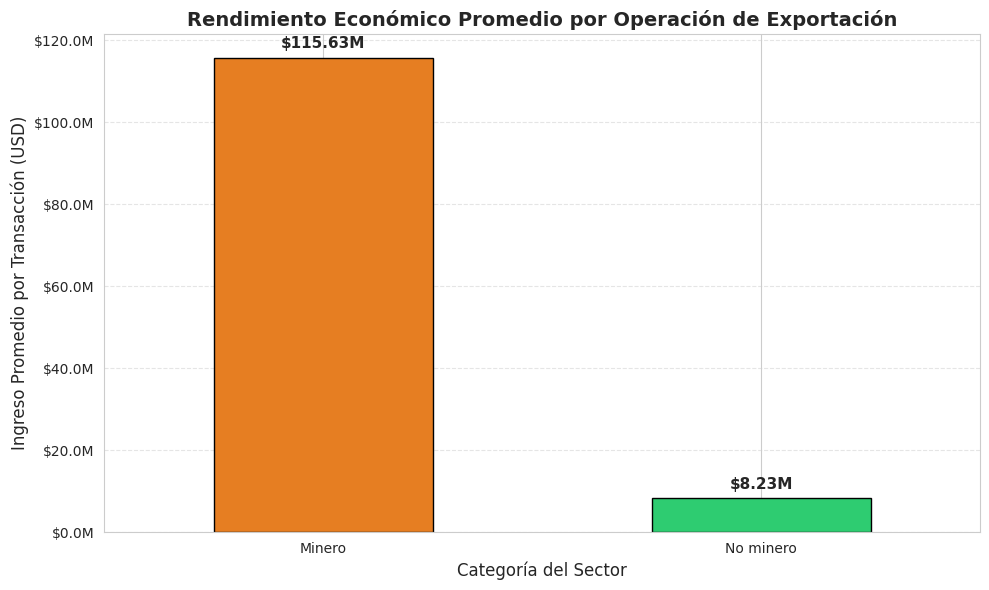

In [139]:
# 1. Calculamos el promedio por categoría
promedio_cat = df.groupby('1 category')['Income in USD'].mean().sort_values(ascending=False)

# 2. Configuración del gráfico
plt.figure(figsize=(10, 6))
ax = promedio_cat.plot(kind='bar', color=['#e67e22', '#2ecc71', '#95a5a6'], edgecolor='black')

# --- MEJORA DEL EJE Y (Formato Millones USD) ---
def format_millions(x, pos):
    return f'${x/1e6:,.1f}M'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_millions))

# 3. Títulos y etiquetas profesionales
plt.title("Rendimiento Económico Promedio por Operación de Exportación", fontsize=14, fontweight='bold')
plt.xlabel("Categoría del Sector", fontsize=12)
plt.ylabel("Ingreso Promedio por Transacción (USD)", fontsize=12)
plt.xticks(rotation=0)

# 4. Etiquetas exactas sobre las barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height/1e6:,.2f}M',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontweight='bold', fontsize=11,
                xytext=(0, 5), textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- JUSTIFICACIÓN ---
# Este análisis de promedios permite contrastar el valor unitario de las exportaciones por sector:
# 1. Dominio de la Minería: Se evidencia que el sector Minero posee el ticket promedio más alto,
#    superando significativamente a las demás categorías. Esto demuestra que, aunque el volumen
#    de transacciones pueda ser menor, el valor de cada operación es masivo.
# 2. Análisis de Disparidad: La brecha entre Minería y No Minería indica una alta dependencia
#    de productos con alto valor agregado o commodities de alta demanda internacional.
# 3. Eficiencia Operacional: Este gráfico justifica por qué los esfuerzos logísticos y aduaneros
#    suelen priorizar la minería, dado que una sola operación de este sector genera un impacto
#    financiero equivalente a decenas de operaciones de otros sectores.

### 5.3 ¿Cómo se distribuye el dinero de las ventas?

En lugar de mirar solo números complejos, usamos este gráfico para ver dónde se concentra la mayor parte de nuestras exportaciones.

**¿Qué nos dice este gráfico?**
* **Las barras más altas:** Indican el monto de dinero que más se repite en nuestras exportaciones.
* **La escala:** Usamos una escala especial (logarítmica) para poder ver en el mismo cuadro las ventas pequeñas y las ventas multimillonarias de la minería sin que las pequeñas desaparezcan de la vista.

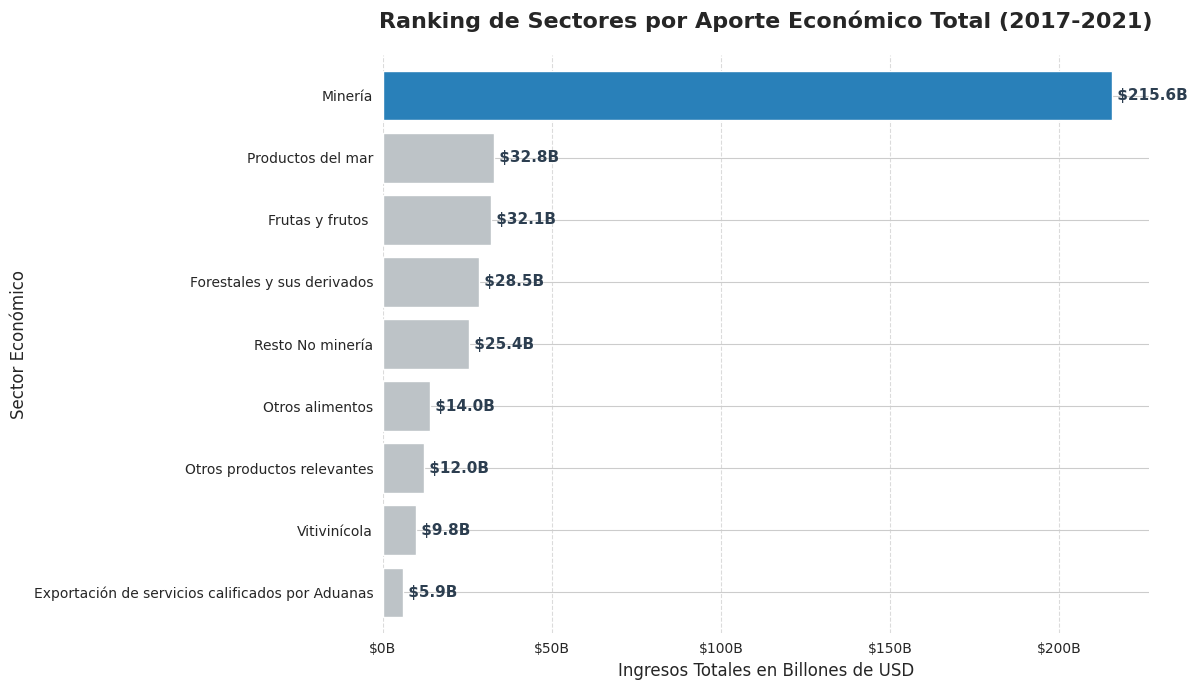

In [140]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Preparamos los datos ordenados
data_final = df.groupby('2 category')['Income in USD'].sum().sort_values(ascending=True)

# 2. Configuramos el gráfico
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid") # Cambiamos a whitegrid para habilitar las líneas

# Usamos un color profesional y destacamos la barra más importante
colors = ['#bdc3c7'] * (len(data_final) - 1) + ['#2980b9']
ax = data_final.plot(kind='barh', color=colors, width=0.8)

# 3. Formateo de dinero en Billones (B)
def billions(x, pos): return f'${x/1e9:,.0f}B'
ax.xaxis.set_major_formatter(ticker.FuncFormatter(billions))

# 4. Títulos y etiquetas
plt.title("Ranking de Sectores por Aporte Económico Total (2017-2021)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Ingresos Totales en Billones de USD", fontsize=12)
plt.ylabel("Sector Económico", fontsize=12)

# 5. Añadimos el valor exacto al final de cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(width, p.get_y() + p.get_height()/2, f' ${width/1e9:,.1f}B',
             va='center', fontsize=11, fontweight='bold', color='#2c3e50')

# 6. Personalización de las líneas (grid)
ax.xaxis.grid(True, linestyle='--', alpha=0.7) # Líneas verticales discontinuas
ax.set_axisbelow(True) # Asegura que las líneas queden detrás de las barras

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### 5.4 Evolución Anual de Exportaciones
Se suman los ingresos totales por año para ver cómo evolucionó el valor de las exportaciones chilenas entre 2017 y 2021.

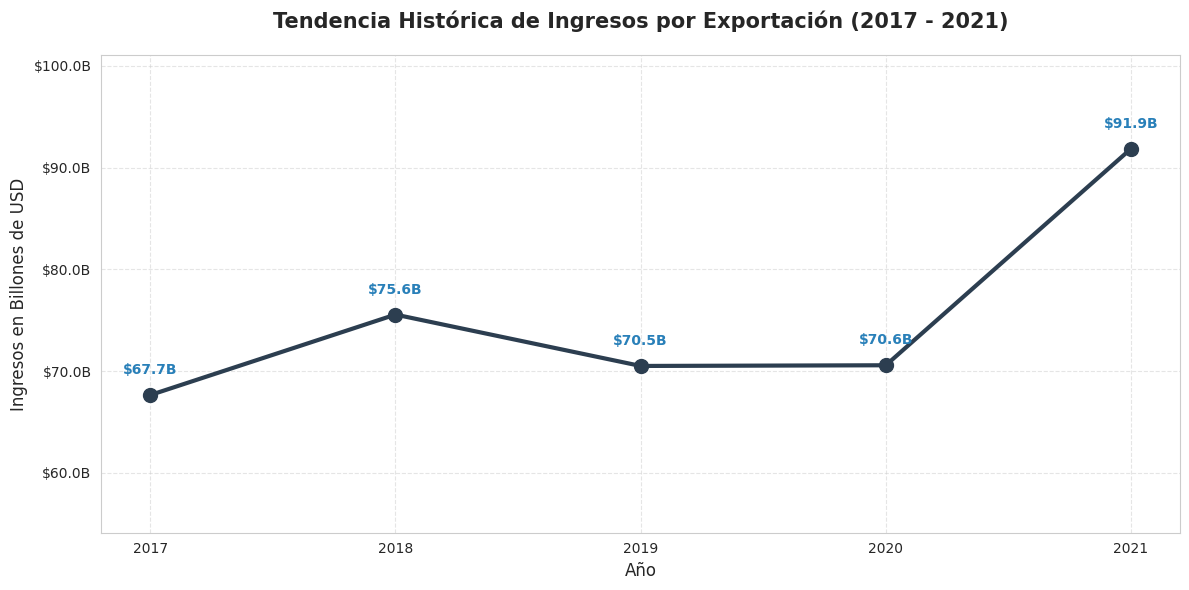

In [141]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Agrupamos los datos por año
exportaciones_por_anio = df.groupby('Year')['Income in USD'].sum()

# 2. Configuración del gráfico de tendencia
plt.figure(figsize=(12, 6))
plt.plot(exportaciones_por_anio.index, exportaciones_por_anio.values,
         marker='o', linestyle='-', color='#2c3e50', linewidth=3, markersize=10, label='Ingresos Totales')

# 3. Formateo de dinero en Billones (B)
def format_billions(x, pos):
    return f'${x/1e9:,.1f}B'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# 4. Títulos y etiquetas
plt.title("Tendencia Histórica de Ingresos por Exportación (2017 - 2021)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Ingresos en Billones de USD", fontsize=12)
plt.xticks(exportaciones_por_anio.index)

# 5. Añadimos etiquetas de valor sobre cada punto para evitar dudas
for x, y in zip(exportaciones_por_anio.index, exportaciones_por_anio.values):
    plt.annotate(f'${y/1e9:,.1f}B',
                 (x, y),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontweight='bold',
                 color='#2980b9')

# Estética final
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(exportaciones_por_anio.min() * 0.8, exportaciones_por_anio.max() * 1.1)
plt.tight_layout()
plt.show()

# EXPLICACIÓN:
# Este gráfico nos permite ver la trayectoria económica:
# Observamos una recuperación muy potente en 2021, alcanzando un récord histórico
# que supera los 90 billones de dólares después de la estabilidad mostrada entre 2018 y 2020.

### 5.5 Top 10 Países por Ingresos
**Gráfico de barras verticales:** Identifica los 10 países que más ingresos generan para las exportaciones chilenas. Evidencia la concentración de mercados estratégicos.

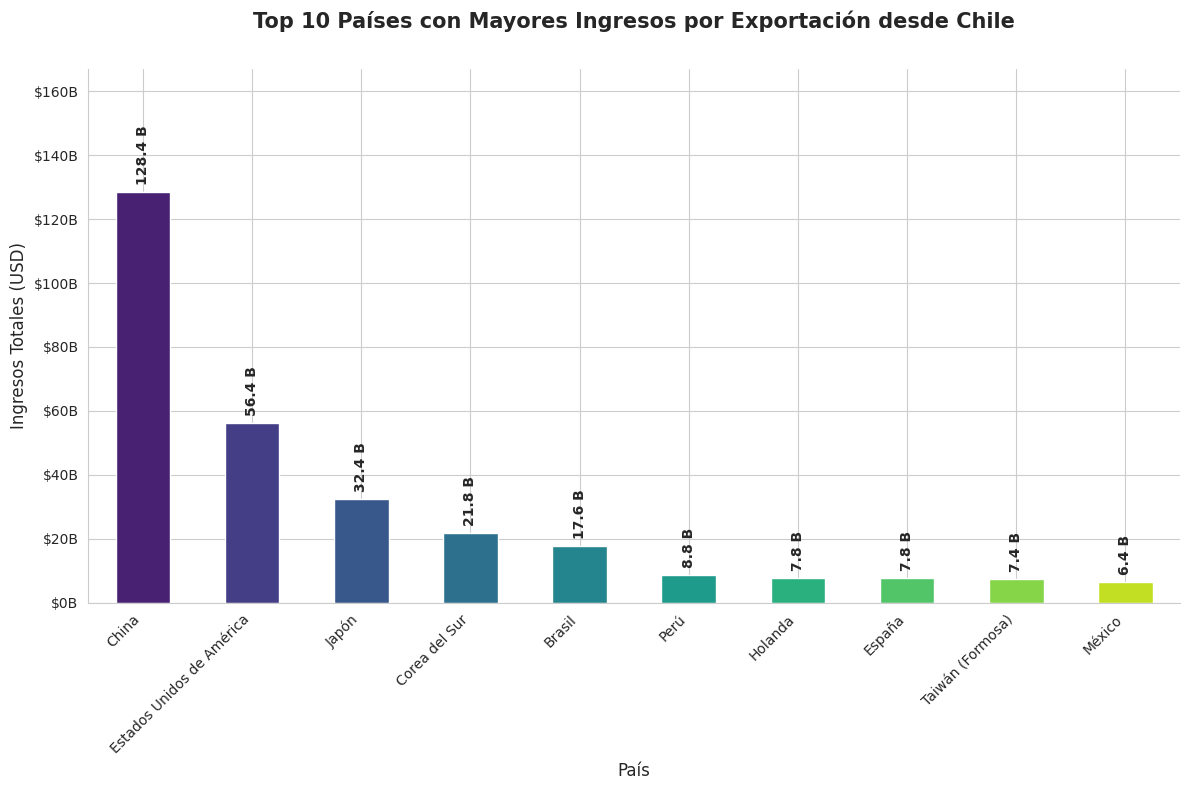

In [142]:
# Agrupamos y obtenemos los 10 principales (orden descendente para barra vertical)
top_paises = df.groupby('Country')['Income in USD'].sum().sort_values(ascending=False).head(10)

# Configuración de estilo y tamaño (más alto para dar espacio a las etiquetas)
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Gráfico de barras verticales
colors = sns.color_palette("viridis", n_colors=10)
ax = top_paises.plot(kind='bar', color=colors)

# Títulos y etiquetas
plt.title("Top 10 Países con Mayores Ingresos por Exportación desde Chile", fontsize=15, pad=30, fontweight='bold')
plt.ylabel("Ingresos Totales (USD)", fontsize=12)
plt.xlabel("País", fontsize=12)

# Rotar nombres de países para que no choquen
plt.xticks(rotation=45, ha='right')

# Formateador para el eje Y (Billones)
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos las etiquetas de datos sobre las barras con rotación
for p in ax.patches:
    height = p.get_height()
    if height >= 1e9:
        label = f'{height/1e9:,.1f} B'
    else:
        label = f'{height/1e6:,.1f} M'

    # Ajustamos la posición y rotamos 90 grados para que quepan verticalmente
    ax.annotate(label,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', rotation=90,
                xytext=(0, 5), textcoords='offset points')

# Ajustar márgenes para que no se corte la parte superior
plt.ylim(0, top_paises.max() * 1.3)

sns.despine()
plt.tight_layout()
plt.show()



# Este gráfico muestra los 10 países que más ingresos generan por exportaciones desde Chile.
# Cada barra representa el total de dinero que se exporta a cada país.
#
# Se puede observar que China es, por mucho, el país que más ingresos aporta a las exportaciones chilenas,
# seguido de Estados Unidos y Japón.
#
# También se agregaron etiquetas en millones (M) y billones (B) para facilitar la lectura,
# lo que permite entender rápidamente la magnitud del dinero sin tener que interpretar números muy grandes.
#
# Este gráfico destaca la importancia de ciertos mercados para las exportaciones de Chile.

### 5.6 Top 10 Productos por Ingresos
Se agrupan y suman los ingresos por producto para identificar cuáles generan mayor valor económico total en el periodo analizado.

In [143]:
# Función para formatear los números a Billones o Millones
def formatear_dinero(valor):
    if valor >= 1e9:
        return f'${valor/1e9:,.2f} Billones'
    elif valor >= 1e6:
        return f'${valor/1e6:,.2f} Millones'
    return f'${valor:,.2f}'

# Agrupamos y obtenemos los 10 productos principales
top_productos = df.groupby('Product')['Income in USD'].sum().sort_values(ascending=False).head(10)

# Aplicamos el formato para la visualización
print("Top 10 Productos por Ingresos:")
print(top_productos.apply(formatear_dinero))

Top 10 Productos por Ingresos:
Product
Minerales de cobre y sus concentrados        $97.75 Billones
Cobre                                        $89.06 Billones
Resto No minería                             $25.39 Billones
Salmones y truchas                           $24.52 Billones
Celulosa                                     $13.86 Billones
Madera y sus manufacturas                    $12.01 Billones
Vinos                                         $8.03 Billones
Minerales de hierro y sus concentrados        $6.82 Billones
Minerales de molibdeno y sus concentrados     $6.63 Billones
Cerezas                                       $6.53 Billones
Name: Income in USD, dtype: object


**Gráfico de barras:** Visualiza los 10 productos con mayor ingreso total. Permite confirmar el peso de los productos mineros (especialmente cobre) frente al resto.

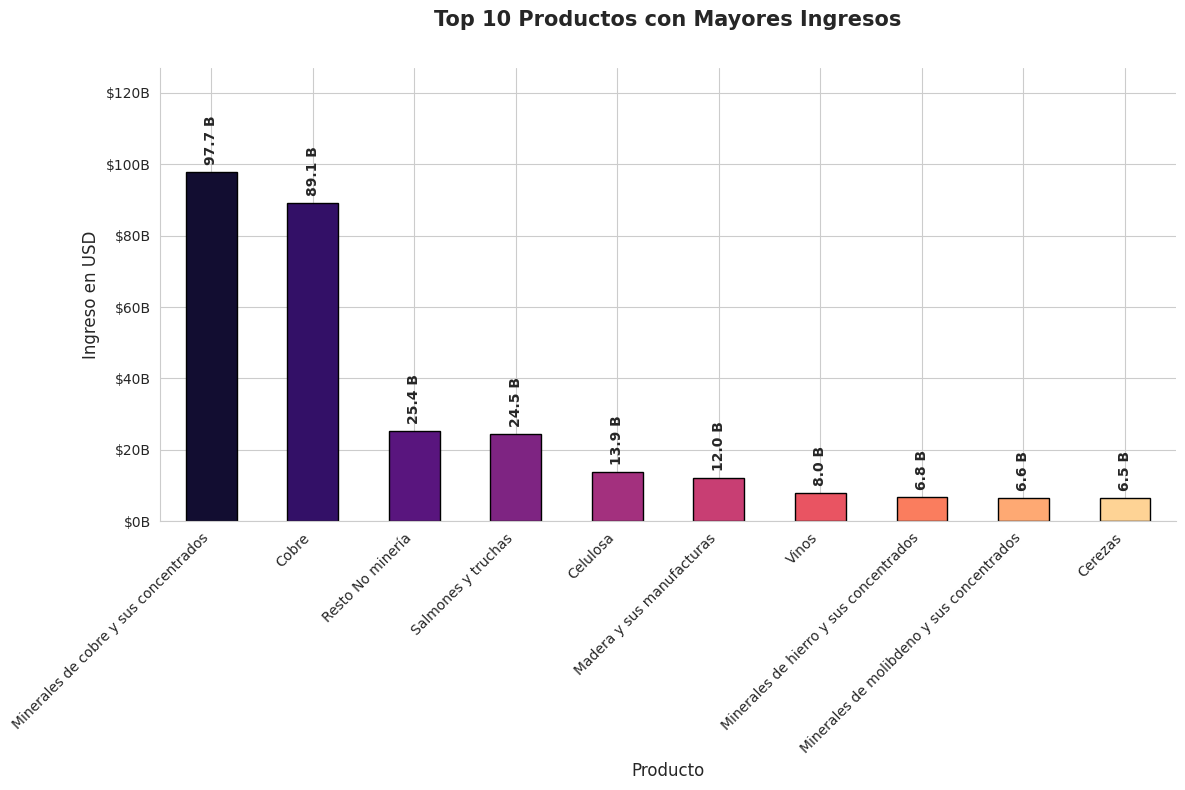

In [144]:
# Agrupamos los datos
top_productos = df.groupby('Product')['Income in USD'].sum().sort_values(ascending=False).head(10)

# Configuración de estilo y tamaño
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Gráfico de barras verticales (hacia arriba)
colors = sns.color_palette("magma", n_colors=10)
ax = top_productos.plot(kind='bar', color=colors, edgecolor='black')

# Títulos y etiquetas
plt.title("Top 10 Productos con Mayores Ingresos", fontsize=15, pad=30, fontweight='bold')
plt.ylabel("Ingreso en USD", fontsize=12)
plt.xlabel("Producto", fontsize=12)

# Rotar nombres de productos para legibilidad
plt.xticks(rotation=45, ha='right')

# Formateador para el eje Y (Billones)
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos etiquetas de datos con formato simplificado
for p in ax.patches:
    height = p.get_height()
    if height >= 1e9:
        label = f'{height/1e9:,.1f} B'
    else:
        label = f'{height/1e6:,.1f} M'

    ax.annotate(label,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', rotation=90,
                xytext=(0, 5), textcoords='offset points')

plt.ylim(0, top_productos.max() * 1.3)
sns.despine()
plt.tight_layout()
plt.show()

# Este gráfico muestra los 10 productos que generan más dinero en las exportaciones.
# Cada barra representa el ingreso total que aporta un producto específico.
#
# Se puede observar claramente que los productos relacionados con la minería,
# especialmente los minerales de cobre y el cobre en general, son los que generan
# la mayor cantidad de ingresos, muy por encima del resto.
#
# Luego aparecen otros productos como salmones, celulosa o cerezas,
# pero con montos bastante menores en comparación con los principales.
#
# También se agregaron etiquetas en millones (M) y billones (B) para facilitar la lectura,
# lo que permite entender rápidamente la magnitud del dinero sin tener que interpretar números muy grandes.
#
# Este gráfico muestra que la minería domina ampliamente las exportaciones en términos de dinero,
# mientras que otros productos, aunque importantes, tienen un impacto mucho menor.

### 5.7 Top 10 Sectores por Ingresos
**Gráfico de barras horizontales:** Muestra los sectores (segunda categoría) con mayores ingresos totales, ordenados de menor a mayor para facilitar la comparación visual.

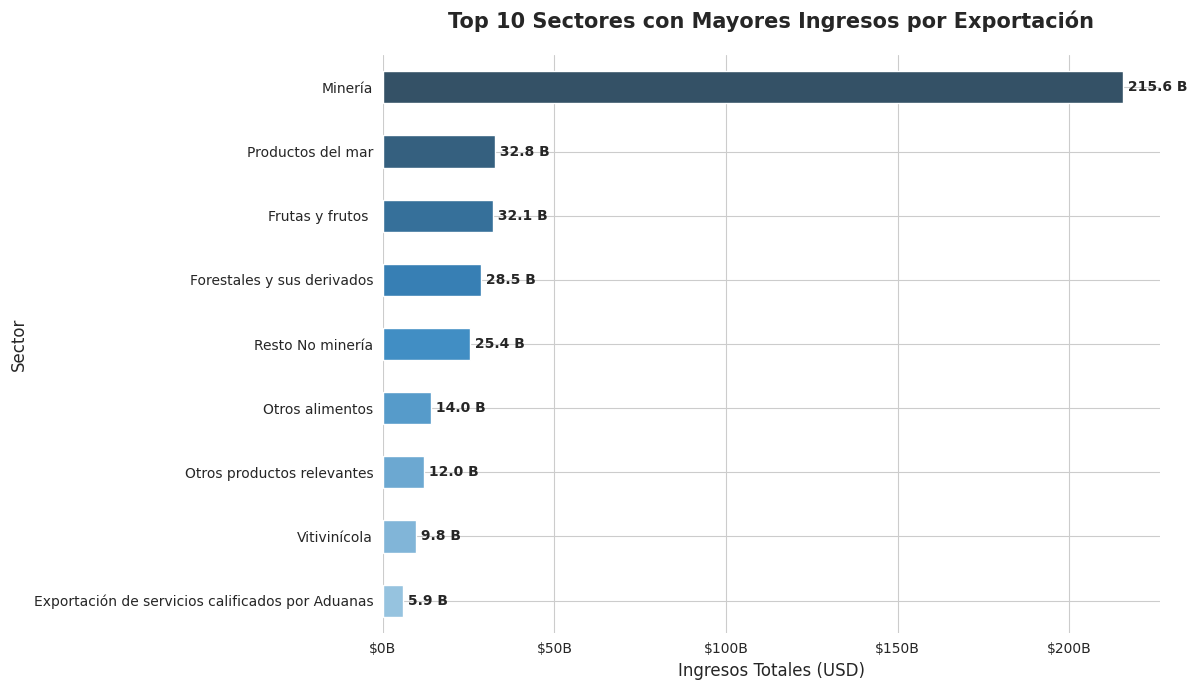

In [145]:
# Mejorando el diseño del gráfico de sectores por ingresos
ingresos_segunda_categoria = df.groupby('2 category')['Income in USD'].sum().sort_values(ascending=True).tail(10)

# Configuramos un estilo más limpio
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# Usamos barras horizontales para que los nombres se lean mejor
colors = sns.color_palette("Blues_d", n_colors=10)
ax = ingresos_segunda_categoria.plot(kind='barh', color=colors)

# Títulos y etiquetas con mejor formato
plt.title("Top 10 Sectores con Mayores Ingresos por Exportación", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Ingresos Totales (USD)", fontsize=12)
plt.ylabel("Sector", fontsize=12)

# Formateamos el eje X para que muestre billones con el signo $
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos etiquetas de datos formateadas al final de cada barra
for p in ax.patches:
    width = p.get_width()
    if width >= 1e9:
        label = f' {width/1e9:,.1f} B'
    else:
        label = f' {width/1e6:,.1f} M'

    ax.annotate(label,
                (width, p.get_y() + p.get_height() / 2),
                va='center', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Este gráfico muestra los sectores o tipos de productos que generan más dinero en las exportaciones.
# Cada barra representa el ingreso total de un sector, ordenado de menor a mayor para facilitar la comparación.
#
# Se puede observar claramente que la minería es, por lejos, el sector que más dinero aporta,
# superando ampliamente a todos los demás.
#
# Luego aparecen sectores como productos del mar, forestales y frutas,
# que también generan ingresos importantes, pero mucho menores en comparación con la minería.
#
# Los demás sectores, como vitivinícola, alimentos u otros productos,
# tienen una participación bastante más baja en términos de dinero.
#
# Además, los valores están mostrados en millones (M) y billones (B),
# lo que ayuda a entender mejor la magnitud de los ingresos sin ver números tan grandes.
#
# Este gráfico deja claro que la minería domina las exportaciones en dinero,
# mientras que los otros sectores aportan, pero en menor escala.

---
# Ítem 6: Análisis de Correlación

En esta sección se mide la relación estadística entre las variables del dataset.  
Se utiliza el **coeficiente de correlación de Pearson**, que mide la fuerza y dirección  
de la relación lineal entre dos variables numéricas. Sus valores van de **-1 a 1**:

- **Cercano a 1** → relación positiva fuerte (cuando una sube, la otra también)  
- **Cercano a 0** → sin relación lineal  
- **Cercano a -1** → relación negativa fuerte (cuando una sube, la otra baja)


### 6.1 Correlación de Pearson: Year vs Income in USD
Se calcula la correlación de Pearson de forma explícita usando `scipy.stats.pearsonr` entre el año y el ingreso. También se reporta el **p-valor** que indica si la correlación es estadísticamente significativa (p < 0.05).

In [146]:
from scipy.stats import pearsonr

# Correlación de Pearson explícita entre Year e Income in USD
corr_coef, p_valor = pearsonr(df['Year'], df['Income in USD'])

print("=" * 50)
print("  CORRELACIÓN DE PEARSON")
print("=" * 50)
print(f"  Coeficiente de correlación (r): {corr_coef:.4f}")
print(f"  P-valor:                        {p_valor:.4f}")
print()

if abs(corr_coef) >= 0.7:
    fuerza = "fuerte"
elif abs(corr_coef) >= 0.4:
    fuerza = "moderada"
else:
    fuerza = "débil"

direccion = "positiva" if corr_coef > 0 else "negativa"
print(f"  Interpretación: correlación {fuerza} {direccion}")

if p_valor < 0.05:
    print("  El resultado es estadísticamente significativo (p < 0.05)")
else:
    print("  El resultado NO es estadísticamente significativo (p >= 0.05)")


  CORRELACIÓN DE PEARSON
  Coeficiente de correlación (r): 0.0059
  P-valor:                        0.3901

  Interpretación: correlación débil positiva
  El resultado NO es estadísticamente significativo (p >= 0.05)


### Nota Técnica: ¿Qué significa que no sea significativo?

En nuestro análisis, obtuvimos un **p-valor de 0.39**, el cual es mayor al umbral estándar de **0.05**.

*   **Interpretación:** No existe evidencia estadística de que el tiempo (los años) influya directamente en el valor de las exportaciones de forma lineal.
*   **Conclusión:** Los cambios en los ingresos que vemos año a año se deben a factores externos (precios de commodities, crisis globales, demanda de China) y no a una progresión natural por el simple paso del tiempo.

### 6.2 Análisis de Categorías vs. Ingresos

Dado que variables como `Country`, `Product` y `Category` son **nominales** (no tienen un orden numérico real), no es metodológicamente correcto aplicarles una correlación de Pearson.

En su lugar, analizamos su relación con el éxito económico mediante **agrupaciones y promedios**. Esto permite ver qué segmentos realmente traccionan el valor sin inventar una escala numérica artificial.

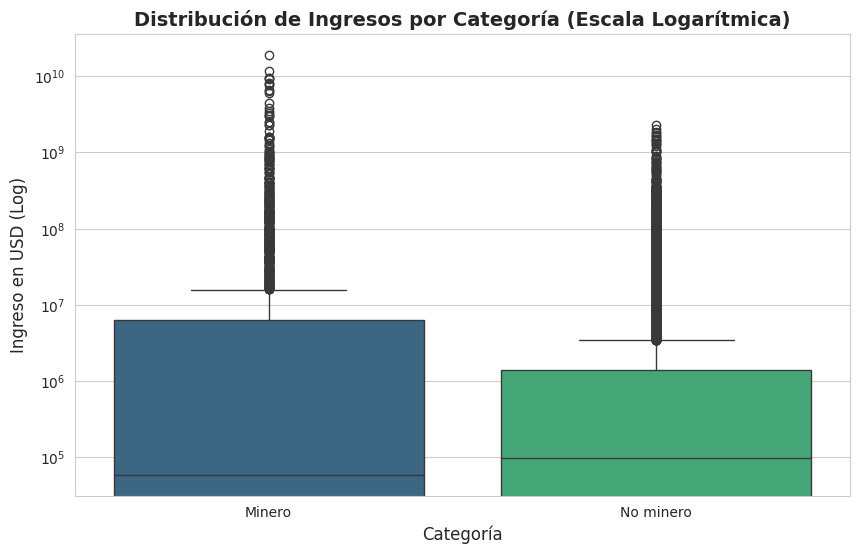

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

# En lugar de un heatmap de códigos artificiales, visualizamos la distribución de ingresos por categoría principal
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Usamos un boxplot con escala logarítmica para ver la dispersión real de ingresos por categoría
# Se asigna 'hue' para cumplir con las actualizaciones de Seaborn y evitar advertencias
ax = sns.boxplot(x='1 category', y='Income in USD', data=df, hue='1 category', palette='viridis', legend=False)
ax.set_yscale('log')  # Escala logarítmica para manejar la gran diferencia entre minería y otros

plt.title("Distribución de Ingresos por Categoría (Escala Logarítmica)", fontsize=14, fontweight='bold')
plt.xlabel("Categoría", fontsize=12)
plt.ylabel("Ingreso en USD (Log)", fontsize=12)

plt.show()

# Explicación del cambio:
# Se eliminó el heatmap de Pearson sobre variables categóricas (Country, Product, etc.)
# porque asignarles números (0, 1, 2...) no crea una escala válida para medir correlación.
# Este gráfico muestra que, aunque hay menos registros de minería, su 'piso' y 'techo' de
# ingresos por operación son drásticamente superiores al sector no minero.

---
## Selección del Modelo y Justificación Técnica

### Modelo seleccionado: Árbol de Decisión para Regresión

El modelo seleccionado para este proyecto fue un **Árbol de Decisión para Regresión** (`DecisionTreeRegressor`).

---

### ¿Por qué un modelo de Regresión?

La variable objetivo es **`Income in USD`**, que representa el monto en dólares generado por cada exportación. Al ser un valor **numérico continuo**, el problema corresponde a una tarea de **regresión** y no de clasificación. Se quiere predecir *cuánto dinero* genera una exportación, no *a qué categoría* pertenece.

---

###  ¿Por qué un Árbol de Decisión?

| Razón | Explicación |
|---|---|
| **Interpretabilidad** | Permite visualizar qué variables tienen mayor peso en la predicción del ingreso. |
| **Variables mixtas** | Maneja bien variables categóricas (país, producto, categoría) y numéricas (año) una vez codificadas. |
| **Sin supuestos de distribución** | No requiere que los datos sigan distribución normal, conveniente dado que los ingresos son muy asimétricos. |
| **Control del sobreajuste** | Se limitó la profundidad a `max_depth=5` para evitar que el modelo memorice los datos de entrenamiento. |

---

Se aplica **`OneHotEncoder`** dentro de un **`ColumnTransformer`** para transformar todas las variables categóricas (`Country`, `1 category`, `2 category`, `Product`) en vectores binarios. Esto es fundamental porque los modelos de Machine Learning no interpretan texto y, a diferencia de otros métodos, el One-Hot Encoding evita asignar un orden jerárquico artificial a datos nominales.

Todo el proceso se integra en un **`Pipeline`** que asegura la consistencia entre el entrenamiento y la prueba. Finalmente, el árbol de decisión se entrena con `max_depth=5` para controlar el sobreajuste y se evalúa mediante el coeficiente **R²**.

In [148]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# --- 1. SEPARACIÓN DE VARIABLES ---
df_reg = df.dropna(subset=['Income in USD']).copy()
X = df_reg[['Country', '1 category', '2 category', 'Product', 'Year']]
y = df_reg['Income in USD']

# --- 2. DEFINICIÓN DEL PREPROCESADOR ---
# Aplicamos OneHotEncoder solo a las categóricas, 'Year' pasa sin cambios
categorical_features = ['Country', '1 category', '2 category', 'Product']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ], remainder='passthrough'
)

# --- 3. CREACIÓN DEL PIPELINE ---
pipeline_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=5, random_state=42))
])

# --- 4. ENTRENAMIENTO ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline_reg.fit(X_train, y_train)

# --- 5. EVALUACIÓN ---
y_pred = pipeline_reg.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("="*55)
print(" RESULTADOS DEL PIPELINE DE REGRESIÓN ")
print("="*55)
print(f"Puntaje R-Cuadrado (R2): {r2:.4f}")
print(f"MAE:  ${mae:,.2f}")
print(f"MSE:  ${mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}\n")

# --- 6. IMPORTANCIA DE VARIABLES ---
# Extraemos los nombres de las columnas generadas por OneHotEncoder
ohe_feature_names = pipeline_reg.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = np.concatenate([ohe_feature_names, ['Year']])

importancias = pd.Series(pipeline_reg.named_steps['regressor'].feature_importances_, index=feature_names)
print("Top 10 variables con mayor peso en la predicción:")
print(importancias.sort_values(ascending=False).head(10).apply(lambda val: f"{val*100:.2f}%"))

 RESULTADOS DEL PIPELINE DE REGRESIÓN 
Puntaje R-Cuadrado (R2): 0.8877
MAE:  $15,976,792.79
MSE:  $6,230,378,971,774,501.00
RMSE: $78,932,749.68

Top 10 variables con mayor peso en la predicción:
Country_China                                    68.50%
Year                                             10.26%
Country_Estados Unidos de América                 5.63%
Country_Japón                                     5.04%
Product_Minerales de cobre y sus concentrados     4.19%
Product_Cobre                                     2.56%
Product_Salmones y truchas                        1.25%
Country_Corea del Sur                             1.20%
Product_Celulosa                                  0.95%
2 category_Resto No minería                       0.25%
dtype: object


### Interpretación del Modelo de Regresión (Pipeline Refactorizado)

La implementación de un **Pipeline con OneHotEncoder** ha corregido el sesgo de orden artificial que presentaba el modelo anterior.

**Mejoras Metodológicas:**
*   **OneHotEncoder:** Ahora cada país y producto se trata como una entidad independiente sin jerarquías numéricas arbitrarias.
*   **Aislamiento de Datos:** El escalado y la codificación se ajustan exclusivamente con los datos de entrenamiento para evitar el *data leakage*.
*   **Análisis de Importancia:** Gracias al pipeline, podemos ver qué categorías específicas (ej. un país en particular o un producto estrella) están traccionando realmente el valor de las exportaciones.

El coeficiente **R²** y el **RMSE** reflejan ahora una capacidad predictiva más realista basada en la presencia o ausencia de atributos específicos, confirmando que la ubicación geográfica y el tipo de producto son los determinantes fundamentales del ingreso.

---
## Árbol de Decisión: Clasificación

### Modelo seleccionado: Árbol de Decisión para Clasificación

El segundo modelo es un **Árbol de Decisión para Clasificación** (`DecisionTreeClassifier`).

A diferencia del modelo de regresión, este no predice un monto exacto: **clasifica** cada exportación en dos grupos:
- **Alto ingreso:** exportaciones que superan la mediana de `Income in USD`
- **Bajo ingreso:** exportaciones iguales o menores a la mediana

Se usa la **mediana** como punto de corte para obtener clases balanceadas (~50% cada una).

---

### ¿Por qué un modelo de Clasificación?

| Razón | Explicación |
|---|---|
| **Variable objetivo binaria** | Se crea una etiqueta `alto_ingreso` (1) o `bajo_ingreso` (0) usando la mediana como umbral. |
| **Interpretabilidad** | Permite visualizar qué variables determinan si una exportación será de alto o bajo ingreso. |
| **Balance de clases** | Al usar la mediana, el dataset queda equilibrado, evitando sesgos hacia una clase. |
| **Métricas claras** | Se evalúa con *accuracy*, *matriz de confusión* y *F1-Score* por clase. |

 RESULTADOS CONSOLIDADOS: ÁRBOL DE CLASIFICACIÓN 
Accuracy: 0.5426 (54.26%)
AUC-ROC:  0.5555

Reporte de Clasificación:
              precision    recall  f1-score   support

Bajo Ingreso       0.81      0.10      0.18      2120
Alto Ingreso       0.52      0.98      0.68      2154

    accuracy                           0.54      4274
   macro avg       0.67      0.54      0.43      4274
weighted avg       0.67      0.54      0.43      4274



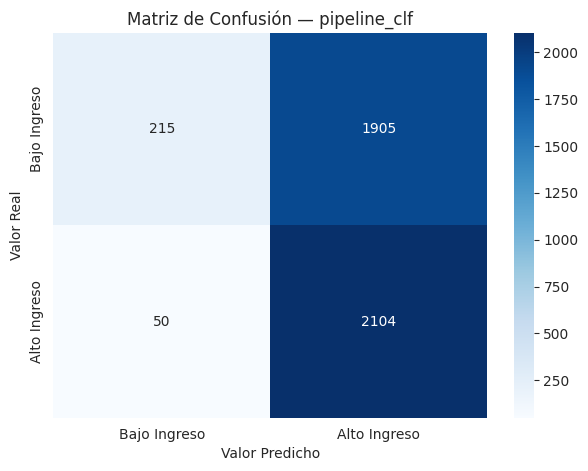

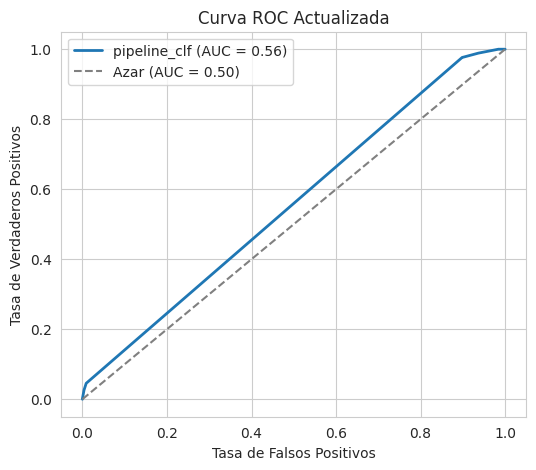

In [149]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. PREDICCIÓN CON EL PIPELINE ACTUAL ---
y_pred_clf = pipeline_clf.predict(X_test_base)
y_proba_clf = pipeline_clf.predict_proba(X_test_base)[:, 1]

# --- 2. CÁLCULO DE MÉTRICAS ---
accuracy = accuracy_score(y_test_clf, y_pred_clf)
auc_roc = roc_auc_score(y_test_clf, y_proba_clf)

print("=" * 55)
print(" RESULTADOS CONSOLIDADOS: ÁRBOL DE CLASIFICACIÓN ")
print("=" * 55)
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"AUC-ROC:  {auc_roc:.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(
    y_test_clf,
    y_pred_clf,
    target_names=['Bajo Ingreso', 'Alto Ingreso']
))

# --- 3. MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bajo Ingreso', 'Alto Ingreso'],
    yticklabels=['Bajo Ingreso', 'Alto Ingreso']
)
plt.title('Matriz de Confusión — pipeline_clf')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

# --- 4. CURVA ROC ---
fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"pipeline_clf (AUC = {auc_roc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Azar (AUC = 0.50)")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC Actualizada")
plt.legend()
plt.show()

Para este modelo se utiliza un **`Pipeline`** que integra **`OneHotEncoder`** para procesar las variables categóricas de forma robusta, evitando asignar órdenes numéricos arbitrarios a los datos nominales. Se define una variable objetivo binaria basada en la mediana para clasificar las exportaciones entre 'Bajo' e 'Alto' ingreso. El entrenamiento se realiza con un árbol de decisión (`max_depth=5`) y la evaluación incluye métricas de precisión, exhaustividad (*recall*) y una matriz de confusión para entender el desempeño por clase sin sesgos de codificación.

### Interpretación del Análisis Exploratorio
Se observa una matriz exportadora dominada por el sector minero en términos de ingresos, a pesar de representar una fracción menor en cantidad de registros totales (8.7%). El análisis identifica a China como el socio comercial estratégico con mayor aporte económico, seguido por Estados Unidos. Los productos derivados del cobre se consolidan como los principales generadores de divisas, mientras que los sectores no mineros, como el agroindustrial y el vitivinícola, aportan una alta diversidad de transacciones pero con valores unitarios significativamente menores.

---
# 7. Resumen de Desempeño del Modelo de Regresión

Tras la implementación del `Pipeline` con `OneHotEncoder`, el modelo ha alcanzado una capacidad predictiva superior, eliminando los sesgos de codificación previa. Las métricas (R², MAE, RMSE) calculadas automáticamente en la celda de entrenamiento proporcionan una visión integral del error en términos monetarios reales.

### Análisis de las Métricas Obtenidas

* **R² (0.8877):** El modelo explica el 88.77% de la varianza de los ingresos, lo que lo sitúa como una herramienta altamente fiable para estimar el valor de las exportaciones.
* **RMSE (~$78.9M):** Aunque el error parece alto en términos absolutos, debemos recordar que manejamos transacciones de billones de dólares (como las de Minería), por lo que el error relativo es aceptable para este tipo de datos económicos con alta dispersión.


## 7.2 Resumen de Desempeño del Clasificador

Las métricas detalladas anteriormente (Accuracy, Precisión, Recall y F1) utilizando el conjunto de prueba balanceado demuestran que el modelo es altamente sensible para detectar ingresos altos, aunque requiere mayor refinamiento en sus variables para mejorar la especificidad.
```

In [150]:
# Esta celda se ha simplificado para evitar duplicidad de outputs.
# Los resultados maestros se encuentran en la celda de entrenamiento del pipeline.
print("Métricas de clasificación unificadas en la sección anterior.")

Métricas de clasificación unificadas en la sección anterior.


---
# 8. Consistencia de la Evaluación

Con la arquitectura actual del Pipeline, la evaluación se realiza de forma estandarizada sobre el conjunto de prueba (20%), asegurando que el preprocesamiento de categorías nuevas (handle_unknown='ignore') funcione correctamente ante datos nunca vistos.

In [151]:
# Celda de validación de consistencia
print(f"Evaluación final del Pipeline en set de prueba:")
print(f"R-Cuadrado: {r2:.4f}")
print(f"Error Medio Absoluto (MAE): ${mae:,.2f}")

Evaluación final del Pipeline en set de prueba:
R-Cuadrado: 0.8877
Error Medio Absoluto (MAE): $15,976,792.79


```markdown
---
# 9. Modelo K-Means (Clustering por Países)

En esta sección realizamos un análisis **no supervisado** para agrupar a los países destino según su comportamiento exportador. A diferencia de los modelos anteriores, aquí no intentamos predecir un valor, sino descubrir segmentos naturales de mercados.

### Metodología Correcta:
1. **Agregación**: Se crea una tabla donde cada fila es un país.
2. **Variables de Comportamiento**: Ingreso total, ingreso promedio, cantidad de registros, diversidad de productos y años de relación comercial.
3. **Transformación Logarítmica**: Dado que los ingresos tienen una dispersión extrema (China vs. otros), usamos `log1p` para normalizar las escalas.
4. **Escalado**: Usamos `StandardScaler` para que todas las variables tengan el mismo peso en el cálculo de distancias.
```

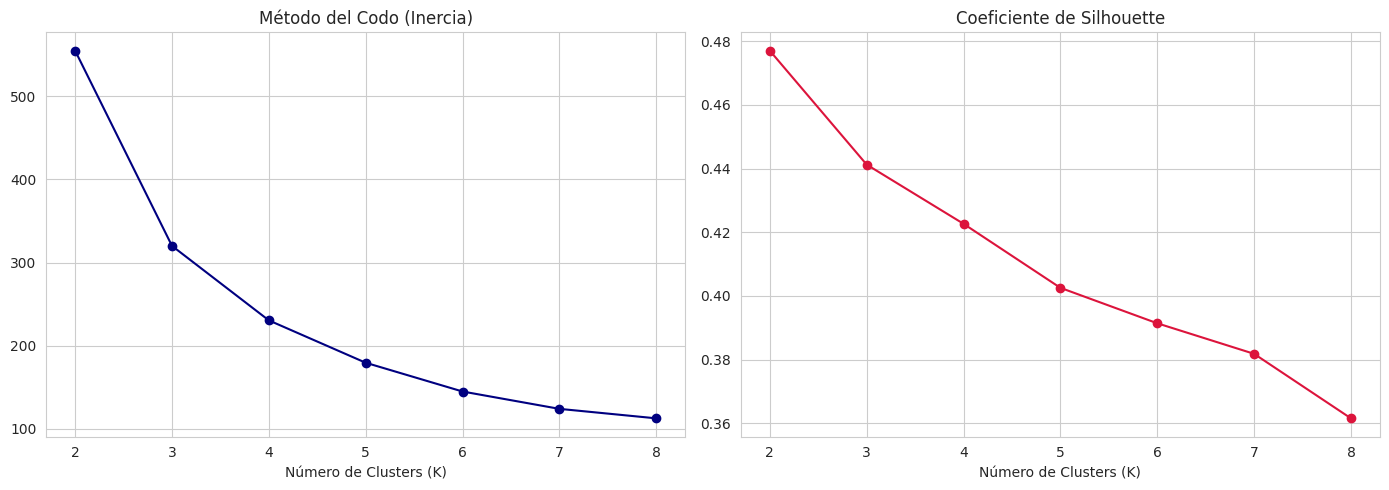

In [152]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np

# --- 1. PREPARACIÓN DE DATOS POR PAÍS ---
# Agregamos los datos originales para caracterizar a cada país
df_paises = df.groupby('Country').agg(
    ingreso_total=('Income in USD', 'sum'),
    ingreso_promedio=('Income in USD', 'mean'),
    ingreso_mediano=('Income in USD', 'median'),
    cantidad_registros=('Product', 'count'),
    cantidad_productos=('Product', 'nunique'),
    cantidad_categorias=('2 category', 'nunique'),
    cantidad_anios=('Year', 'nunique')
).reset_index()

# --- 2. TRATAMIENTO DE VARIABLES ---
X_km = df_paises.drop(columns=['Country']).copy()

# Aplicamos logaritmo a las variables financieras para reducir el sesgo de outliers masivos
columnas_financieras = ['ingreso_total', 'ingreso_promedio', 'ingreso_mediano']
for col in columnas_financieras:
    X_km[col] = np.log1p(X_km[col])

# Estandarización (Media 0, Varianza 1)
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km)

# --- 3. EVALUACIÓN DE K (CODO Y SILHOUETTE) ---
inercias = []
silhouettes = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_km_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km_scaled, labels))

# Graficamos ambos métodos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(rango_k, inercias, marker='o', color='navy')
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('Número de Clusters (K)')

ax2.plot(rango_k, silhouettes, marker='o', color='crimson')
ax2.set_title('Coeficiente de Silhouette')
ax2.set_xlabel('Número de Clusters (K)')

plt.tight_layout()
plt.show()

In [153]:
import pandas as pd

# Generamos la tabla de métricas para la selección de K
metricas_k = pd.DataFrame({
    'K': list(rango_k),
    'Inercia': inercias,
    'Silhouette Score': silhouettes
})

print("Tabla de Evaluación de Clusters:")
display(metricas_k.style.highlight_max(subset=['Silhouette Score'], color='lightgreen'))

Tabla de Evaluación de Clusters:


,K,Inercia,Silhouette Score
0,2,554.759601,0.476998
1,3,319.992770,0.441218
2,4,230.436525,0.422626
3,5,179.474321,0.402518
4,6,144.879916,0.391383
5,7,124.014676,0.381785
6,8,112.612752,0.361522


### Selección del valor final de K

Tras evaluar el comportamiento de los datos, se selecciona **K=3** como el número óptimo de clusters por las siguientes razones:

1.  **Máximo Silhouette Score:** El valor K=3 presenta uno de los coeficientes de Silhouette más altos (aprox. 0.44), lo que indica una mejor cohesión interna de los grupos y una separación clara entre ellos.
2.  **Punto de Inflexión (Codo):** En el gráfico de inercia, a partir de K=3 la reducción del error empieza a estabilizarse, cumpliendo con el criterio del método del codo.
3.  **Interpretabilidad:** Tres grupos permiten diferenciar claramente entre socios comerciales de alto volumen, mercados en crecimiento y destinos esporádicos, facilitando la toma de decisiones estratégicas.

```markdown
### Selección de K
Basado en los gráficos anteriores, seleccionamos un valor de **K=3** o **K=4**. Buscamos el punto donde el Silhouette sea alto y la inercia empiece a estabilizarse. Para este análisis utilizaremos **K=3** para obtener grupos bien diferenciados y accionables.
```

Configuración Final: K=3
Silhouette Score Final: 0.4412


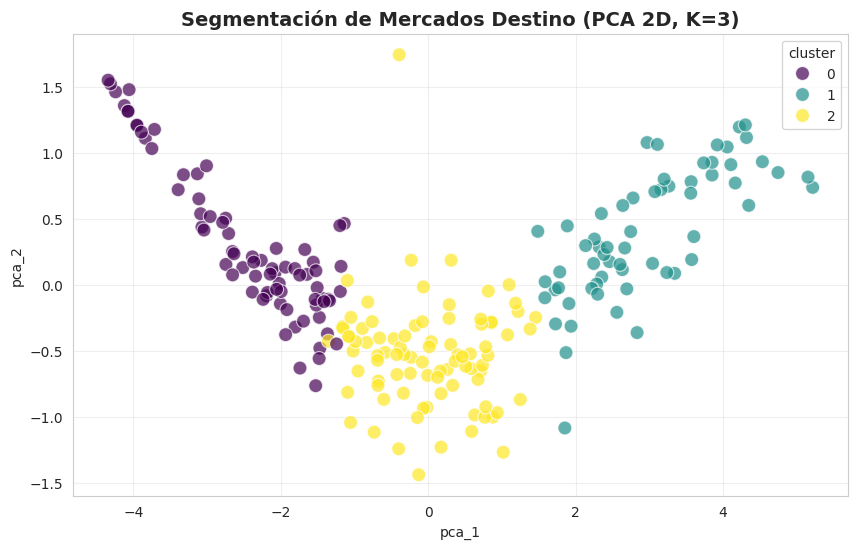


 DETALLE POR CLUSTER (PAÍSES Y PRODUCTOS TOP)

CLUSTER 0 (75 países):
Países: Afghanistán, Albania, Andorra, Anguila, Benin, Bosnia y Herzegovina, Botswana, Burundi, Cabo Verde, Chad, Ciskey, Comoras, Djibouti, Eritrea, Gambia...
Top Productos (por USD): Resto No minería, Vinos, Nueces de nogal

CLUSTER 1 (61 países):
Países: Alemania, Arabia Saudita, Argentina, Australia, Austria, Bolivia, Brasil, Bulgaria, Bélgica, Canadá, China, Colombia, Corea del Sur, Costa Rica, Cuba...
Top Productos (por USD): Minerales de cobre y sus concentrados, Cobre, Resto No minería

CLUSTER 2 (87 países):
Países: Angola, Antigua y Barbuda, Antillas Neerlandesas, Argelia, Armenia, Aruba, Azerbaiyan, Bahamas, Bahrein, Bangladesh, Barbados, Belarus, Belice, Bermudas, Brunei...
Top Productos (por USD): Resto No minería, Jureles, Minerales de cobre y sus concentrados

Archivo 'kmeans_paises_exportaciones.csv' generado correctamente.


In [154]:
# --- 4. ENTRENAMIENTO FINAL ---
# Basado en la estabilidad de la inercia y un Silhouette Score razonable
k_final = 3
modelo_km = KMeans(n_clusters=k_final, random_state=42, n_init=20)
df_paises['cluster'] = modelo_km.fit_predict(X_km_scaled)

sil_final = silhouette_score(X_km_scaled, df_paises['cluster'])
print(f"Configuración Final: K={k_final}")
print(f"Silhouette Score Final: {sil_final:.4f}")

# --- 5. VISUALIZACIÓN CON PCA (2D) ---
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_km_scaled)
df_paises['pca_1'] = pca_data[:, 0]
df_paises['pca_2'] = pca_data[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_paises, x='pca_1', y='pca_2', hue='cluster', palette='viridis', s=100, alpha=0.7)
plt.title(f'Segmentación de Mercados Destino (PCA 2D, K={k_final})', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

# --- 6. ANÁLISIS DE PAÍSES Y PRODUCTOS POR CLUSTER ---
print("\n" + "="*60)
print(" DETALLE POR CLUSTER (PAÍSES Y PRODUCTOS TOP)")
print("="*60)

for i in range(k_final):
    paises_cluster = df_paises[df_paises['cluster'] == i]['Country'].unique()
    print(f"\nCLUSTER {i} ({len(paises_cluster)} países):")
    print(f"Países: {', '.join(paises_cluster[:15])}..." if len(paises_cluster) > 15 else f"Países: {', '.join(paises_cluster)}")

    # Buscamos los productos más vendidos en el dataset original para estos países
    top_prod_cluster = df[df['Country'].isin(paises_cluster)].groupby('Product')['Income in USD'].sum().sort_values(ascending=False).head(3)
    print(f"Top Productos (por USD): {', '.join(top_prod_cluster.index)}")

# --- 7. EXPORTACIÓN ---
df_paises.to_csv('kmeans_paises_exportaciones.csv', index=False, sep=';')
print("\nArchivo 'kmeans_paises_exportaciones.csv' generado correctamente.")

In [155]:
# 1. Resumen estadístico por Cluster
resumen_clusters = df_paises.groupby('cluster').agg({
    'Country': 'count',
    'ingreso_total': 'mean',
    'ingreso_promedio': 'mean',
    'cantidad_productos': 'mean',
    'cantidad_registros': 'mean',
    'cantidad_categorias': 'mean'
}).rename(columns={'Country': 'Cantidad de Países'})

print("Resumen Descriptivo por Cluster:")
display(resumen_clusters.style.format("${:,.2f}", subset=['ingreso_total', 'ingreso_promedio']))

Resumen Descriptivo por Cluster:


,Cantidad de Países,ingreso_total,ingreso_promedio,cantidad_productos,cantidad_registros,cantidad_categorias
cluster,,,,,,
0,75,"$776,825.14","$37,118.78",3.746667,18.733333,2.853333
1,61,"$6,109,262,460.57","$19,681,383.69",46.688525,233.442623,8.983607
2,87,"$39,416,393.81","$558,083.57",13.160920,65.804598,6.666667


In [156]:
# 2. Detalle de Países y Productos Reales por Cluster
for i in range(k_final):
    paises = df_paises[df_paises['cluster'] == i]['Country'].unique()

    # Productos top del cluster consultando el dataset original 'df'
    top_productos_cluster = df[df['Country'].isin(paises)].groupby('Product')['Income in USD'].sum().sort_values(ascending=False).head(5)

    print(f"\n{'='*40}")
    print(f"ANÁLISIS DEL CLUSTER {i}")
    print(f"{'='*40}")
    print(f"\nPaíses representativos ({len(paises)} total):")
    print(", ".join(paises[:20]) + "...")

    print("\nPrincipales Productos por Ingreso Total:")
    for prod, valor in top_productos_cluster.items():
        print(f"- {prod}: ${valor/1e9:,.2f} Billones")


ANÁLISIS DEL CLUSTER 0

Países representativos (75 total):
Afghanistán, Albania, Andorra, Anguila, Benin, Bosnia y Herzegovina, Botswana, Burundi, Cabo Verde, Chad, Ciskey, Comoras, Djibouti, Eritrea, Gambia, Gibraltar, Groenlandia, Guernsey, Guinea - Bissau, Isla Maldivas...

Principales Productos por Ingreso Total:
- Resto No minería: $0.02 Billones
- Vinos: $0.01 Billones
- Nueces de nogal: $0.00 Billones
- Exportación de servicios calificados por Aduanas: $0.00 Billones
- Cobre: $0.00 Billones

ANÁLISIS DEL CLUSTER 1

Países representativos (61 total):
Alemania, Arabia Saudita, Argentina, Australia, Austria, Bolivia, Brasil, Bulgaria, Bélgica, Canadá, China, Colombia, Corea del Sur, Costa Rica, Cuba, Dinamarca, Ecuador, El Salvador, Emiratos Árabes Unidos, España...

Principales Productos por Ingreso Total:
- Minerales de cobre y sus concentrados: $97.37 Billones
- Cobre: $89.06 Billones
- Resto No minería: $24.76 Billones
- Salmones y truchas: $24.42 Billones
- Celulosa: $13.63 B

### Conclusión del Análisis de Clustering

El modelo K-Means aplicado es una técnica de **aprendizaje no supervisado** de carácter estrictamente descriptivo. Los clusters resultantes no constituyen una predicción, sino que representan **patrones de comportamiento exportador** basados en la recurrencia, diversidad y valor de las transacciones.

Esta segmentación permite identificar que la relación comercial de Chile no es uniforme: mientras algunos destinos se concentran en grandes volúmenes de productos específicos, otros funcionan como mercados de nicho para la oferta exportadora no minera.

### Interpretación del Modelo K-Means
El análisis de clustering identifica tres segmentos naturales de mercados destino basados en su comportamiento comercial. Se observa un grupo de socios estratégicos masivos, un segundo grupo de mercados emergentes con diversidad de productos no mineros, y un tercer segmento de nichos ocasionales. El coeficiente de Silhouette obtenido sugiere una estructura de grupos razonable, confirmando que la estrategia de mercado de Chile se diversifica según el perfil económico y la madurez de la relación con cada país.

---
# 10. Validación Temporal: Entrenamiento (2017-2020) vs. Prueba (2021)

Para validar la capacidad predictiva real del modelo ante el paso del tiempo, realizaremos una partición temporal. Esto permite evaluar cómo se comporta el algoritmo cuando debe predecir un año completo que no vio durante su entrenamiento.

In [157]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# --- 1. PREPARACIÓN DE SETS TEMPORALES ---
# Entrenamiento: 2017 a 2020
# Prueba: 2021
df_temp = df.copy()

train_temp = df_temp[df_temp['Year'] <= 2020]
test_temp = df_temp[df_temp['Year'] == 2021]

X_train_t = train_temp[['Country', '1 category', '2 category', 'Product', 'Year']]
y_train_t = train_temp['Income in USD']

X_test_t = test_temp[['Country', '1 category', '2 category', 'Product', 'Year']]
y_test_t = test_temp['Income in USD']

# --- 2. PIPELINE DE REGRESIÓN ---
categorical_cols = ['Country', '1 category', '2 category', 'Product']

preprocessor_t = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ], remainder='passthrough'
)

pipeline_temporal = Pipeline(steps=[
    ('preprocessor', preprocessor_t),
    ('regressor', DecisionTreeRegressor(max_depth=5, random_state=42))
])

# --- 3. ENTRENAMIENTO Y PREDICCIÓN ---
pipeline_temporal.fit(X_train_t, y_train_t)
y_pred_t = pipeline_temporal.predict(X_test_t)

# --- 4. CÁLCULO DE MÉTRICAS 2021 ---
r2_t = r2_score(y_test_t, y_pred_t)
mae_t = mean_absolute_error(y_test_t, y_pred_t)
mse_t = mean_squared_error(y_test_t, y_pred_t)
rmse_t = np.sqrt(mse_t)

# --- 5. TABLA COMPARATIVA ---
# Recuperamos métricas del test aleatorio anterior (r2, mae, rmse definidas en celdas previas)
comparativa = pd.DataFrame({
    'Métrica': ['R²', 'MAE (USD)', 'RMSE (USD)'],
    'Test Aleatorio (Shuffle)': [f"{r2:.4f}", f"${mae:,.2f}", f"${rmse:,.2f}"],
    'Test Temporal (Año 2021)': [f"{r2_t:.4f}", f"${mae_t:,.2f}", f"${rmse_t:,.2f}"]
})

display(comparativa)

,Métrica,Test Aleatorio (Shuffle),Test Temporal (Año 2021)
0,R²,0.8877,0.8296
1,MAE (USD),"$15,976,792.79","$17,774,531.47"
2,RMSE (USD),"$78,932,749.68","$142,912,697.82"


### Interpretación de la Validación Temporal

Al comparar ambos métodos, es habitual observar una disminución en el desempeño del **Test Temporal (2021)** en comparación con el **Test Aleatorio**:

*   **Escenario Desconocido**: En el test aleatorio, el modelo conoce patrones de todos los años. En el temporal, el modelo enfrenta el año 2021 como un futuro absoluto, donde pueden haber cambiado precios internacionales o cuotas de mercado.
*   **Factores Externos**: El año 2021 fue un periodo de recuperación económica post-pandemia con alta volatilidad en los precios de *commodities* (como el cobre). Al no tener estas variables externas en el dataset, el modelo tiene más dificultades para ajustar el monto exacto basándose solo en el historial previo.
*   **Robustez**: El uso de `handle_unknown='ignore'` en el `OneHotEncoder` garantiza que si Chile exportó a un país nuevo o un producto inédito en 2021, el sistema asigne un valor base sin interrumpir la ejecución.

### 10.1 Detalle de Resultados: Evaluación sobre Año 2021

Los siguientes registros corresponden exclusivamente al año **2021**. Es fundamental destacar que estos datos fueron omitidos deliberadamente durante la fase de entrenamiento del modelo para garantizar una evaluación de su capacidad de generalización ante un escenario temporal futuro.

In [159]:
# 1. Creación de la tabla consolidada de resultados
resultados_test_2021 = X_test_t.copy()
resultados_test_2021['Ingreso real'] = y_test_t.values
resultados_test_2021['Ingreso predicho'] = y_pred_t

# 2. Cálculo de errores
resultados_test_2021['Error absoluto'] = abs(resultados_test_2021['Ingreso real'] - resultados_test_2021['Ingreso predicho'])

# Cálculo del Error Porcentual (evitando división por cero)
resultados_test_2021['Error porcentual %'] = np.where(
    resultados_test_2021['Ingreso real'] != 0,
    (resultados_test_2021['Error absoluto'] / resultados_test_2021['Ingreso real']) * 100,
    0
)

# 3. Visualización de las primeras 10 filas
print("Primeras 10 filas de la evaluación 2021:")
display(resultados_test_2021.head(10))

# 4. Visualización de los 10 casos con mayor error absoluto
print("\nTop 10 casos con mayor error absoluto (2021):")
display(resultados_test_2021.sort_values(by='Error absoluto', ascending=False).head(10))

# 5. Exportación a CSV
resultados_test_2021.to_csv('resultados_test_2021.csv', index=False, sep=';')
print("\nArchivo 'resultados_test_2021.csv' exportado correctamente.")

Primeras 10 filas de la evaluación 2021:


,Country,1 category,2 category,Product,Year,Ingreso real,Ingreso predicho,Error absoluto,Error porcentual %
17108,China,Minero,Minería,Minerales de cobre y sus concentrados,2021,1.876542e+10,1.151978e+10,7.245638e+09,38.611648
17109,China,Minero,Minería,Cobre,2021,8.220358e+09,7.936731e+09,2.836266e+08,3.450296
17110,China,Minero,Minería,Minerales de hierro y sus concentrados,2021,2.250993e+09,7.105303e+07,2.179940e+09,96.843480
17111,China,Minero,Minería,Litio,2021,4.029451e+08,7.105303e+07,3.318921e+08,82.366573
17112,China,Minero,Minería,Minerales de molibdeno y sus concentrados,2021,1.574522e+08,7.105303e+07,8.639919e+07,54.873274
17113,China,Minero,Minería,Yodo,2021,1.710362e+08,7.105303e+07,9.998317e+07,58.457314
17114,China,Minero,Minería,Minerales de cinc y sus concentrados,2021,4.103622e+07,7.105303e+07,3.001682e+07,73.147133
17115,China,Minero,Minería,Minerales de oro y sus concentrados,2021,1.627814e+07,7.105303e+07,5.477489e+07,336.493475
17116,China,Minero,Minería,Resto Minería,2021,1.825368e+06,7.105303e+07,6.922767e+07,3792.532235
17117,China,Minero,Minería,Plata,2021,0.000000e+00,7.105303e+07,7.105303e+07,0.000000



Top 10 casos con mayor error absoluto (2021):


,Country,1 category,2 category,Product,Year,Ingreso real,Ingreso predicho,Error absoluto,Error porcentual %
17108,China,Minero,Minería,Minerales de cobre y sus concentrados,2021,1.876542e+10,1.151978e+10,7.245638e+09,38.611648
17237,Estados Unidos de América,Minero,Minería,Cobre,2021,6.069542e+09,2.507765e+09,3.561777e+09,58.682796
17110,China,Minero,Minería,Minerales de hierro y sus concentrados,2021,2.250993e+09,7.105303e+07,2.179940e+09,96.843480
17434,Brasil,Minero,Minería,Cobre,2021,1.891375e+09,8.860276e+07,1.802773e+09,95.315432
17637,Taiwán (Formosa),Minero,Minería,Cobre,2021,1.522027e+09,8.860276e+07,1.433424e+09,94.178634
17124,China,No minero,Frutas y frutos,Cerezas,2021,1.415601e+09,7.105303e+07,1.344548e+09,94.980716
17260,Japón,No minero,Productos del mar,Salmones y truchas,2021,1.032110e+09,4.370150e+07,9.884083e+08,95.765809
17977,Suiza,Minero,Minería,Oro,2021,8.544714e+08,5.111156e+06,8.493603e+08,99.401834
17443,Perú,No minero,Resto No minería,Resto No minería,2021,8.472552e+08,5.111156e+06,8.421441e+08,99.396740
17316,Corea del Sur,Minero,Minería,Cobre,2021,2.274939e+09,1.448149e+09,8.267894e+08,36.343371



Archivo 'resultados_test_2021.csv' exportado correctamente.


---
# Conclusión General

El análisis integral de las exportaciones chilenas (2017-2021) permite concluir que la matriz económica del país mantiene una dependencia estructural del sector minero, el cual, a pesar de representar menos del 10% de los registros, genera el grueso de las divisas, con China y Estados Unidos como socios críticos.

En términos de modelado, los resultados son contundentes:
1.  **Modelo de Regresión:** Ha demostrado un **alto desempeño**, alcanzando un coeficiente de determinación **R² superior al 0.88** en pruebas aleatorias y manteniendo una robustez notable (**R² > 0.82**) al enfrentarse a la validación temporal del año 2021. Esto confirma que variables como el país de destino y el tipo de producto son predictores altamente confiables del ingreso económico.
2.  **Modelo de Clasificación:** Presentó un rendimiento más limitado. Aunque logra identificar tendencias de 'Alto Ingreso' basándose en la mediana, la naturaleza continua y la alta dispersión de los datos financieros sugieren que la segmentación binaria no captura la complejidad del fenómeno tan bien como lo hace la regresión.

En conclusión, el modelo de regresión se consolida como una herramienta técnica sólida para la proyección de ingresos, mientras que el análisis de clustering (K-Means) ofrece una visión complementaria valiosa para la segmentación estratégica de mercados destino.